<a href="https://colab.research.google.com/github/abeeraz379/weather-data-from-London-Time-series-/blob/main/weather_data_from_London(Time_series).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load the data

In [66]:
import pandas as pd


In [67]:

url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vT_jChgNsQbHbg4TGepzIqk8XC9DTIKmyyxb1upo5cfZCgbfIUQc2ZC0YMzuU5uApP140Ob49KBjdqh/pub?gid=1198589591&single=true&output=csv"

df = pd.read_csv(url, parse_dates=["date"])

df.head()


,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,1979-01-01,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,1979-01-02,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,1979-01-03,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,1979-01-04,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,1979-01-05,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              15341 non-null  datetime64[ns]
 1   cloud_cover       14938 non-null  float64       
 2   sunshine          14957 non-null  float64       
 3   global_radiation  14939 non-null  float64       
 4   max_temp          14951 non-null  float64       
 5   mean_temp         14922 non-null  float64       
 6   min_temp          14955 non-null  float64       
 7   precipitation     14951 non-null  float64       
 8   pressure          14953 non-null  float64       
 9   snow_depth        13589 non-null  float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 1.2 MB


# Convert the date column to datetime dtype.

In [69]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')


# Set the date column as the index.

In [70]:
df.set_index("date", inplace=True)

# Filter out only the required data:
Keep only data from the year 2000 or later.
-
 Keep only the following features:
- precipitation
- mean_temp
- min_temp
- max_temp
- snow_depth

In [71]:
df = df[df.index.year >= 2000]

In [72]:

df = df[[
    "precipitation",
    "mean_temp",
    "min_temp",
    "max_temp",
    "snow_depth"
]]


# Impute any missing values.
Think about each feature and what imputation method makes sense. You may not be able to use the same method for every feature!

In [73]:
df['precipitation'] = df['precipitation'].fillna(0)
df['snow_depth']    = df['snow_depth'].fillna(0)


In [74]:
ts_interp = df.interpolate()
df.update(ts_interp)

In [75]:
df.isna().sum()

,0
precipitation,0
mean_temp,0
min_temp,0
max_temp,0
snow_depth,0


# Q1: What month had the most precipitation between 2000 through 2010?
- Resample the precipitation column to a Monthly frequency using .sum() as the aggregation method
- Find the date and corresponding value for the max precipitation.
- Plot the feature and time period that corresponds to the question.
- Make sure to meet the "Visualization Requirements" below!
Determine the date and value for the most precipitation (the max precipitation).
- Add a vertical line at this date with a label that says the date (using date format: "April 2000") and the max precipitation value.
- Make sure to add a legend so that your label is visible.
Visualization Issue Workaround

In [76]:

print(df.index.min())
print(df.index.max())


2000-01-01 00:00:00
2020-12-31 00:00:00


In [77]:
monthly_precip = df["precipitation"].resample("M").sum()
monthly_2000_2010 = monthly_precip.loc["2000":"2010"]
max_date = monthly_2000_2010.idxmax()
max_value = monthly_2000_2010.max()


/tmp/ipykernel_7518/3336037252.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_precip = df["precipitation"].resample("M").sum()


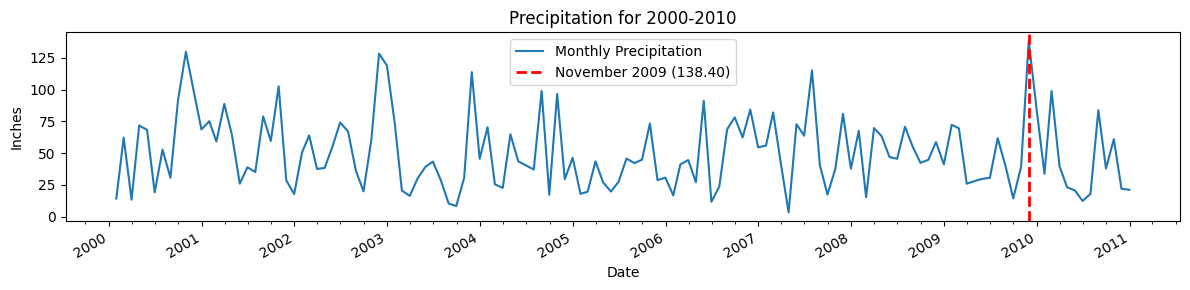

In [78]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 3))

ax.plot(monthly_2000_2010.index, monthly_2000_2010.values,
        label="Monthly Precipitation")

ax.axvline(max_date,
           color="red",
           linestyle="--",
           linewidth=2,
           label=f"{max_date.strftime('%B %Y')} ({max_value:.2f})")

ax.set_title("Precipitation for 2000-2010")
ax.set_ylabel("Inches")
ax.set_xlabel("Date")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

plt.setp(ax.get_xticklabels(), rotation=90)

fig.autofmt_xdate()

ax.legend()

plt.tight_layout()


# Q2: Which year between 2000-2020 had the coolest average temperature?
- Resample the  mean_temp data to a Yearly frequency using .mean() as the aggregation method.

- Plot the feature and time period that corresponds to the question.
- Make sure to meet the "Visualization Requirements" below!
- Determine the year and value for the lowest mean temp.
- Add a vertical line at this date with a label that says the date (using date format: "2000") and the lowest mean temperature value.

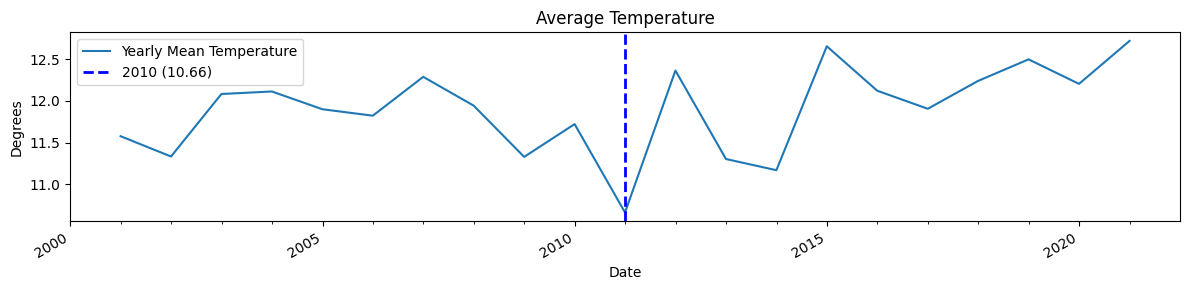

In [79]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

yearly_temp = df["mean_temp"].resample("YE").mean()

min_date = yearly_temp.idxmin()
min_value = yearly_temp.min()

fig, ax = plt.subplots(figsize=(12, 3))

ax.plot(yearly_temp.index, yearly_temp.values, label="Yearly Mean Temperature")

ax.axvline(min_date,
           color="blue",
           linestyle="--",
           linewidth=2,
           label=f"{min_date.strftime('%Y')} ({min_value:.2f})")

ax.set_title("Average Temperature")
ax.set_ylabel("Degrees")
ax.set_xlabel("Date")

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.xaxis.set_minor_locator(mdates.YearLocator(1))

plt.setp(ax.get_xticklabels(), rotation=90)

fig.autofmt_xdate()

ax.legend()

plt.tight_layout()
plt.show()
